# Figure 5 SEEG Radius Dependence



This notebook is a clean radius-dependence re-analysis for the SEEG Figure 5 results.



It reuses the saved correlation table at `../data/df_results/ieeg_metrics/df_correlations_5MOIs_ieeg.csv`, keeps only `Radius_post = 100`, plots mean Pearson correlations across `Radius_pre`, and tests whether larger radii yield larger explained variance `\rho^2` using session-wise slopes summarized at the participant level. This conservative re-analysis avoids treating repeated radii within the same session as independent residual observations and saves the example panel, the five selected metric-pair panels, and the heatmap into `../results/figures/`.

In [1]:
from pathlib import Path

import warnings

import matplotlib.pyplot as plt

import numpy as np

import pandas as pd

import seaborn as sns

from scipy.stats import ttest_1samp, wilcoxon

import statsmodels.formula.api as smf

from statsmodels.tools.sm_exceptions import ConvergenceWarning



LABEL_ORDER = ['ZCR', 'Salience', 'Entrainment', 'Fluidity', 'Complexity']

cwd = Path.cwd().resolve()

if (cwd / 'data').exists():

    project_root = cwd

elif (cwd.parent / 'data').exists():

    project_root = cwd.parent

else:

    raise FileNotFoundError('Could not find project root containing data/.')

correlations_path = project_root / 'data' / 'df_results' / 'ieeg_metrics' / 'df_correlations_5MOIs_ieeg.csv'

figure_dir = project_root / 'results' / 'figures'

figure_dir.mkdir(parents=True, exist_ok=True)

FIGURE_PATHS = {

    'example': figure_dir / 'Figure_5_A.png',

    'stacked': figure_dir / 'Suppl_Figure_6.png',

    'heatmap': figure_dir / 'Figure_5_B.png',

}

df_radius = pd.read_csv(correlations_path)

df_radius = df_radius[df_radius['Radius_post'] == 100].copy()

df_radius['Participant'] = df_radius['Participant'].astype(str)

df_radius['Session'] = df_radius['Session'].astype(str)

df_radius['Session_ID'] = df_radius['Participant'] + '_' + df_radius['Session']

df_radius['Explained_Variance'] = df_radius['Correlation'] ** 2

pair_order = list(LABEL_ORDER)

print(f'Reloaded saved correlations from: {correlations_path}')

print(f'Rows with Radius_post = 100: {len(df_radius):,}')

print(f"Participant-session pairs: {df_radius[['Participant', 'Session']].drop_duplicates().shape[0]}")

for name, path in FIGURE_PATHS.items():

    print(f"{name} figure path: {path}")

df_radius.head()


Reloaded saved correlations from: /Users/cbc/Documents/GitHub/fufo/notebook/DavideMomi/Revision/State_Dependent_Brain_Stimulation-main/data/df_results/ieeg_metrics/df_correlations_5MOIs_ieeg.csv
Rows with Radius_post = 100: 87,450
Participant-session pairs: 318
example figure path: /Users/cbc/Documents/GitHub/fufo/notebook/DavideMomi/Revision/State_Dependent_Brain_Stimulation-main/results/figures/Figure_5_A.png
stacked figure path: /Users/cbc/Documents/GitHub/fufo/notebook/DavideMomi/Revision/State_Dependent_Brain_Stimulation-main/results/figures/Suppl_Figure_6.png
heatmap figure path: /Users/cbc/Documents/GitHub/fufo/notebook/DavideMomi/Revision/State_Dependent_Brain_Stimulation-main/results/figures/Figure_5_B.png


,Participant,Session,Radius_pre,Radius_post,Metric_pre,Metric_post,Correlation,p_value,Network,Session_ID,Explained_Variance
50,P1,S1,5,100,ZCR,ZCR,0.185929,0.250688,SalVentAttn,P1_S1,0.034570
51,P1,S1,5,100,ZCR,Salience,-0.197925,0.220859,SalVentAttn,P1_S1,0.039174
52,P1,S1,5,100,ZCR,Entrainment,-0.288562,0.070951,SalVentAttn,P1_S1,0.083268
53,P1,S1,5,100,ZCR,Fluidity,-0.298073,0.061746,SalVentAttn,P1_S1,0.088848
54,P1,S1,5,100,ZCR,Complexity,0.354547,0.024786,SalVentAttn,P1_S1,0.125704


# Helper Functions



These utilities prepare metric-pair subsets, summarize session-wise slopes of explained variance, and generate the radius-dependence plots on raw Pearson correlations.

In [2]:
def fisher_z_mean(values):
    """Average correlations using Fisher Z-transform and back-transform."""
    series = pd.Series(values).dropna()
    if series.empty:
        return np.nan
    clipped = np.clip(series.to_numpy(dtype=float), -0.999999, 0.999999)
    return np.tanh(np.mean(np.arctanh(clipped)))


def prepare_pair_radius_data(correlations_df, pre_metric, post_metric):
    pair_df = correlations_df[
        (correlations_df['Metric_pre'] == pre_metric)
        & (correlations_df['Metric_post'] == post_metric)
    ].dropna(subset=['Correlation']).copy()
    pair_df['Radius_pre'] = pair_df['Radius_pre'].astype(float)
    pair_df['Explained_Variance'] = pair_df['Correlation'] ** 2
    display_df = (
        pair_df.groupby(['Participant', 'Radius_pre'], observed=True)['Correlation']
        .agg(fisher_z_mean)
        .reset_index()
        .sort_values(['Participant', 'Radius_pre'])
    )
    return pair_df.sort_values(['Participant', 'Session', 'Radius_pre']), display_df


def summarize_radius_trend(pair_df):
    session_rows = []
    for (participant, session), sub_df in pair_df.groupby(['Participant', 'Session'], observed=True):
        sub_df = sub_df[['Radius_pre', 'Explained_Variance']].dropna().sort_values('Radius_pre')
        if sub_df['Radius_pre'].nunique() < 2:
            continue
        radius_pre = sub_df['Radius_pre'].to_numpy(dtype=float)
        explained_variance = sub_df['Explained_Variance'].to_numpy(dtype=float)
        slope_ev, intercept_ev = np.polyfit(radius_pre, explained_variance, 1)
        session_rows.append({
            'Participant': participant,
            'Session': session,
            'Slope_EV': slope_ev,
            'Intercept_EV': intercept_ev,
        })
    if not session_rows:
        raise ValueError('No session-wise slopes could be computed for the requested metric pair.')
    session_slopes = pd.DataFrame(session_rows)
    participant_slopes = (
        session_slopes.groupby('Participant', observed=True, as_index=False)['Slope_EV']
        .mean()
        .rename(columns={'Slope_EV': 'Mean_Slope_EV'})
    )
    slope_values = participant_slopes['Mean_Slope_EV'].to_numpy(dtype=float)
    ttest_result = ttest_1samp(slope_values, popmean=0.0, alternative='greater')
    wilcoxon_p = np.nan
    if not np.allclose(slope_values, 0.0):
        try:
            wilcoxon_p = wilcoxon(slope_values, alternative='greater').pvalue
        except ValueError:
            wilcoxon_p = np.nan
    return {
        'mean_participant_slope_ev': float(np.mean(slope_values)),
        'ttest_p': float(ttest_result.pvalue),
        'wilcoxon_p': float(wilcoxon_p) if not np.isnan(wilcoxon_p) else np.nan,
        'n_participants': int(len(participant_slopes)),
        'n_sessions': int(len(session_slopes)),
        'participant_slopes': participant_slopes,
        'session_slopes': session_slopes,
    }


def plot_radius_lines(display_df, pre_metric, post_metric, trend_summary, ax=None, show_xlabel=True):
    if ax is None:
        _, ax = plt.subplots(figsize=(5.5, 3.4))
    participants = sorted(display_df['Participant'].unique())
    cmap = plt.get_cmap('Reds')
    if len(participants) == 1:
        colors = [cmap(0.6)]
    else:
        colors = [cmap(0.3 + 0.4 * index / (len(participants) - 1)) for index in range(len(participants))]
    for participant, color in zip(participants, colors):
        sub_df = display_df[display_df['Participant'] == participant]
        ax.plot(sub_df['Radius_pre'], sub_df['Correlation'], marker='o', color=color, alpha=0.8)
    ax.axhline(0, color='black', linestyle='--', linewidth=1)
    mean_slope = trend_summary['mean_participant_slope_ev']
    p_value = trend_summary['wilcoxon_p']
    ax.set_xlabel('Radius pre' if show_xlabel else '', fontsize=12)
    ax.set_ylabel(r'$\langle \rho \rangle$', fontsize=12)
    ax.set_title(f'{pre_metric} (t<0) -> {post_metric} (t>0)', fontsize=14)
    ax.grid(True)
    # Curves show Fisher-Z-averaged Pearson correlation, while inference uses participant-level mean session slopes on rho^2.
    ax.text(
        0.97,
        0.85,
        rf'mean slope$_{{\rho^2}}$ = {mean_slope:.4f}, $p = {p_value:.3g}$',
        transform=ax.transAxes,
        fontsize=9,
        ha='right',
        va='bottom',
        bbox=dict(facecolor='white', alpha=0.8),
    )
    return ax


# Example Radius Trend



Example radius-versus-mean-Pearson-correlation plot for `Fluidity -> ZCR`, using only `Radius_post = 100`. The annotation summarizes a conservative participant-level trend test on session-wise slopes of explained variance `\rho^2`.

Saved figure: /Users/cbc/Documents/GitHub/fufo/notebook/DavideMomi/Revision/State_Dependent_Brain_Stimulation-main/results/figures/Figure_5_A.png


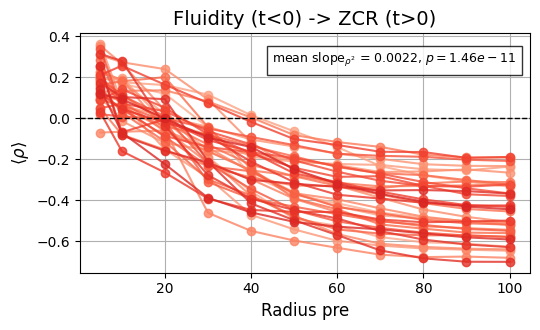

In [3]:
pair_df_zcr, display_df_zcr = prepare_pair_radius_data(df_radius, 'Fluidity', 'ZCR')

zcr_trend_summary = summarize_radius_trend(pair_df_zcr)

example_summary_df = pd.DataFrame([

    {

        'Metric_pre': 'Fluidity',

        'Metric_post': 'ZCR',

        'Mean participant slope on rho^2': zcr_trend_summary['mean_participant_slope_ev'],

        'Wilcoxon p (greater)': zcr_trend_summary['wilcoxon_p'],

        't-test p (greater)': zcr_trend_summary['ttest_p'],

        'Participants': zcr_trend_summary['n_participants'],

        'Sessions': zcr_trend_summary['n_sessions'],

    }

])

fig, ax = plt.subplots(figsize=(5.5, 3.4))

plot_radius_lines(display_df_zcr, 'Fluidity', 'ZCR', zcr_trend_summary, ax=ax)

fig.tight_layout()

fig.savefig(FIGURE_PATHS['example'], dpi=300, bbox_inches='tight')

print(f"Saved figure: {FIGURE_PATHS['example']}")

example_summary_df

plt.show()


# Five Selected Metric Pairs



Five stacked panels for `Complexity -> Entrainment`, `Entrainment -> Complexity`, `Entrainment -> Entrainment`, `Fluidity -> Complexity`, and `Fluidity -> Fluidity`, all at `Radius_post = 100`. The annotations summarize conservative participant-level trend tests on session-wise slopes of explained variance `\rho^2`.

Saved figure: /Users/cbc/Documents/GitHub/fufo/notebook/DavideMomi/Revision/State_Dependent_Brain_Stimulation-main/results/figures/Suppl_Figure_6.png


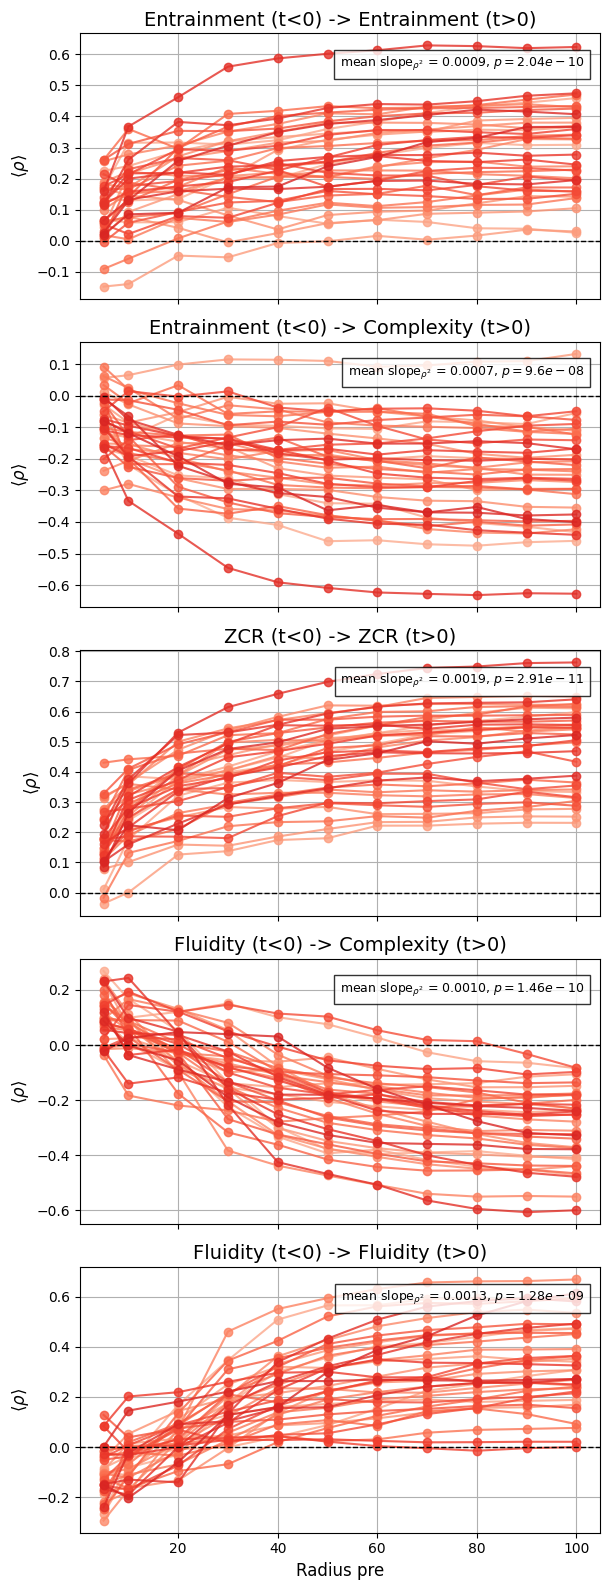

In [4]:
selected_pairs = [

    ('Entrainment', 'Entrainment'),

    ('Entrainment', 'Complexity'),

    ('ZCR', 'ZCR'),

    ('Fluidity', 'Complexity'),

    ('Fluidity', 'Fluidity'),

]

trend_rows = []

fig, axes = plt.subplots(nrows=len(selected_pairs), ncols=1, figsize=(6.2, 16), sharex=True)

for ax, (pre_metric, post_metric) in zip(axes, selected_pairs):

    pair_df, display_df = prepare_pair_radius_data(df_radius, pre_metric, post_metric)

    trend_summary = summarize_radius_trend(pair_df)

    trend_rows.append({

        'Metric_pre': pre_metric,

        'Metric_post': post_metric,

        'Mean participant slope on rho^2': trend_summary['mean_participant_slope_ev'],

        'Wilcoxon p (greater)': trend_summary['wilcoxon_p'],

        't-test p (greater)': trend_summary['ttest_p'],

        'Participants': trend_summary['n_participants'],

        'Sessions': trend_summary['n_sessions'],

    })

    plot_radius_lines(display_df, pre_metric, post_metric, trend_summary, ax=ax, show_xlabel=ax is axes[-1])

fig.tight_layout()

fig.savefig(FIGURE_PATHS['stacked'], dpi=300, bbox_inches='tight')

print(f"Saved figure: {FIGURE_PATHS['stacked']}")

trend_summary_df = pd.DataFrame(trend_rows)

trend_summary_df

plt.show()


# Heatmap



Standardized heatmap of mean explained variance across `Radius_pre`, again using only `Radius_post = 100`.

Saved figure: /Users/cbc/Documents/GitHub/fufo/notebook/DavideMomi/Revision/State_Dependent_Brain_Stimulation-main/results/figures/Figure_5_B.png


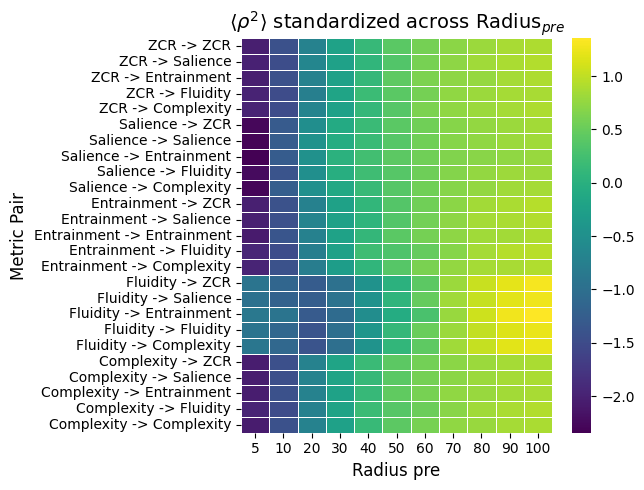

Radius_pre,5,10,20,30,40,50,60,70,80,90,100
Metric_Pair,,,,,,,,,,,
ZCR -> ZCR,0.070834,0.110379,0.157359,0.189873,0.212204,0.230600,0.242268,0.250115,0.255796,0.260843,0.262715
ZCR -> Salience,0.054563,0.081274,0.125165,0.146210,0.162926,0.177265,0.189970,0.197116,0.202217,0.205081,0.207327
ZCR -> Entrainment,0.050543,0.069556,0.092308,0.106811,0.118000,0.128070,0.133906,0.137207,0.138498,0.140970,0.142357
ZCR -> Fluidity,0.048356,0.063765,0.087408,0.105707,0.116975,0.124427,0.129754,0.134733,0.136877,0.138531,0.139278
ZCR -> Complexity,0.047794,0.061268,0.084456,0.096359,0.106625,0.113763,0.120544,0.123812,0.125373,0.126968,0.128373
Salience -> ZCR,0.083660,0.140011,0.183631,0.208268,0.222983,0.236571,0.245561,0.252290,0.256345,0.259599,0.261585
Salience -> Salience,0.122499,0.193006,0.246724,0.274017,0.289789,0.304515,0.316282,0.324754,0.329451,0.333446,0.334969
Salience -> Entrainment,0.065454,0.096920,0.120676,0.135775,0.142065,0.147808,0.151735,0.154664,0.155802,0.157266,0.158375
Salience -> Fluidity,0.059432,0.083989,0.109099,0.123013,0.129669,0.134867,0.139398,0.143016,0.145552,0.147365,0.147282


In [33]:
heatmap_df = df_radius.copy()

heatmap_df['Metric_pre'] = pd.Categorical(heatmap_df['Metric_pre'], categories=pair_order, ordered=True)

heatmap_df['Metric_post'] = pd.Categorical(heatmap_df['Metric_post'], categories=pair_order, ordered=True)

heatmap_summary = (

    heatmap_df.groupby(['Metric_pre', 'Metric_post', 'Radius_pre'], observed=True)['Explained_Variance']

    .mean()

    .reset_index()

)

heatmap_summary['Metric_Pair'] = (

    heatmap_summary['Metric_pre'].astype(str) + ' -> ' + heatmap_summary['Metric_post'].astype(str)

)

heatmap_data = heatmap_summary.pivot(index='Metric_Pair', columns='Radius_pre', values='Explained_Variance')

heatmap_index = [f'{pre} -> {post}' for pre in pair_order for post in pair_order]

heatmap_data = heatmap_data.reindex(index=heatmap_index)

row_std = heatmap_data.std(axis=1).replace(0, np.nan)

heatmap_data_standardized = heatmap_data.sub(heatmap_data.mean(axis=1), axis=0)

heatmap_data_standardized = heatmap_data_standardized.div(row_std, axis=0)

fig, ax = plt.subplots(figsize=(6.5, 5))

sns.heatmap(heatmap_data_standardized, cmap='viridis', linewidths=0.5, cbar_kws={'label': ''}, ax=ax)

ax.set_xlabel('Radius pre', fontsize=12)

ax.set_ylabel('Metric Pair', fontsize=12)

ax.set_title(r'$\langle\rho^2 \rangle$ standardized across Radius$_{pre}$', fontsize=14)

fig.tight_layout()

fig.savefig(FIGURE_PATHS['heatmap'], dpi=300, bbox_inches='tight')

print(f"Saved figure: {FIGURE_PATHS['heatmap']}")

plt.show()

heatmap_data


# Local-vs-Global Radius Comparison

This sensitivity analysis addresses the reviewer's concern by repeating the radius-dependence analysis for multiple post-stimulation spatial extents. Here, `Radius_post` is varied across `5`, `50`, and `100`, while the effect of `Radius_pre` on explained variance `\rho^2` is re-estimated for all metric pairs. The goal is to determine whether the radius dependence is specific to a global post-stimulation target (`Radius_post = 100`) or remains qualitatively similar when the post-stimulation metric is computed more locally.

In [61]:
POST_RADIUS_VALUES = [5, 50, 100]

radius_post_comparison_path = figure_dir / 'Suppl_Figure_radius_post_comparison_SEEG.png'

df_radius_post_compare = pd.read_csv(correlations_path)
df_radius_post_compare['Participant'] = df_radius_post_compare['Participant'].astype(str)
df_radius_post_compare['Session'] = df_radius_post_compare['Session'].astype(str)
df_radius_post_compare['Session_ID'] = (
    df_radius_post_compare['Participant'] + '_' + df_radius_post_compare['Session']
)
df_radius_post_compare['Explained_Variance'] = df_radius_post_compare['Correlation'] ** 2
df_radius_post_compare = df_radius_post_compare[
    df_radius_post_compare['Radius_post'].isin(POST_RADIUS_VALUES)
].copy()

comparison_rows = []
for radius_post in POST_RADIUS_VALUES:
    radius_post_df = df_radius_post_compare[
        df_radius_post_compare['Radius_post'] == radius_post
    ].copy()
    for pre_metric in pair_order:
        for post_metric in pair_order:
            pair_df, _ = prepare_pair_radius_data(radius_post_df, pre_metric, post_metric)
            if pair_df.empty:
                continue
            try:
                trend_summary = summarize_radius_trend(pair_df)
            except ValueError:
                continue
            comparison_rows.append({
                'Radius_post': radius_post,
                'Metric_pre': pre_metric,
                'Metric_post': post_metric,
                'Mean participant slope on rho^2': trend_summary['mean_participant_slope_ev'],
                'Wilcoxon p (greater)': trend_summary['wilcoxon_p'],
                't-test p (greater)': trend_summary['ttest_p'],
                'Participants': trend_summary['n_participants'],
                'Sessions': trend_summary['n_sessions'],
            })

comparison_summary_df = pd.DataFrame(comparison_rows)
comparison_summary_df['Metric_Pair'] = (
    comparison_summary_df['Metric_pre'] + ' -> ' + comparison_summary_df['Metric_post']
)

radius_post_overview_df = (
    comparison_summary_df.groupby('Radius_post', as_index=False)
    .agg(
        Mean_Slope_EV=('Mean participant slope on rho^2', 'mean'),
        Median_Slope_EV=('Mean participant slope on rho^2', 'median'),
        Positive_Slope_Pairs=('Mean participant slope on rho^2', lambda values: int((values > 0).sum())),
        Tested_Pairs=('Metric_Pair', 'nunique'),
    )
    .sort_values('Radius_post')
)

print(f'Rows retained for comparison: {len(df_radius_post_compare):,}')
print(f'Saved comparison figure path: {radius_post_comparison_path}')
radius_post_overview_df

Rows retained for comparison: 262,350
Saved comparison figure path: /Users/cbc/Documents/GitHub/fufo/notebook/DavideMomi/Revision/State_Dependent_Brain_Stimulation-main/results/figures/Suppl_Figure_radius_post_comparison_SEEG.png


,Radius_post,Mean_Slope_EV,Median_Slope_EV,Positive_Slope_Pairs,Tested_Pairs
0,5,-0.000258,-0.000221,9,25
1,50,0.000863,0.000760,25,25
2,100,0.001188,0.000979,25,25


Saved figure: /Users/cbc/Documents/GitHub/fufo/notebook/DavideMomi/Revision/State_Dependent_Brain_Stimulation-main/results/figures/Suppl_Figure_radius_post_comparison_SEEG.png


,Radius_post,Metric_pre,Metric_post,Mean participant slope on rho^2,Wilcoxon p (greater),t-test p (greater),Participants,Sessions,Metric_Pair
3,5,ZCR,Fluidity,0.000287,0.000001,5.437076e-07,36,318,ZCR -> Fluidity
18,5,Fluidity,Fluidity,0.000286,0.000003,3.650953e-06,36,318,Fluidity -> Fluidity
23,5,Complexity,Fluidity,0.000284,0.000002,2.516155e-06,36,318,Complexity -> Fluidity
13,5,Entrainment,Fluidity,0.000253,0.000080,3.207092e-05,36,318,Entrainment -> Fluidity
8,5,Salience,Fluidity,0.000230,0.000007,3.148416e-06,36,318,Salience -> Fluidity
16,5,Fluidity,Salience,0.000199,0.000869,1.559282e-03,36,318,Fluidity -> Salience
15,5,Fluidity,ZCR,0.000195,0.000273,2.917100e-03,36,318,Fluidity -> ZCR
17,5,Fluidity,Entrainment,0.000085,0.135814,7.425619e-02,36,318,Fluidity -> Entrainment
19,5,Fluidity,Complexity,0.000002,0.404951,4.867241e-01,36,318,Fluidity -> Complexity
7,5,Salience,Entrainment,-0.000162,0.999077,9.977806e-01,36,318,Salience -> Entrainment


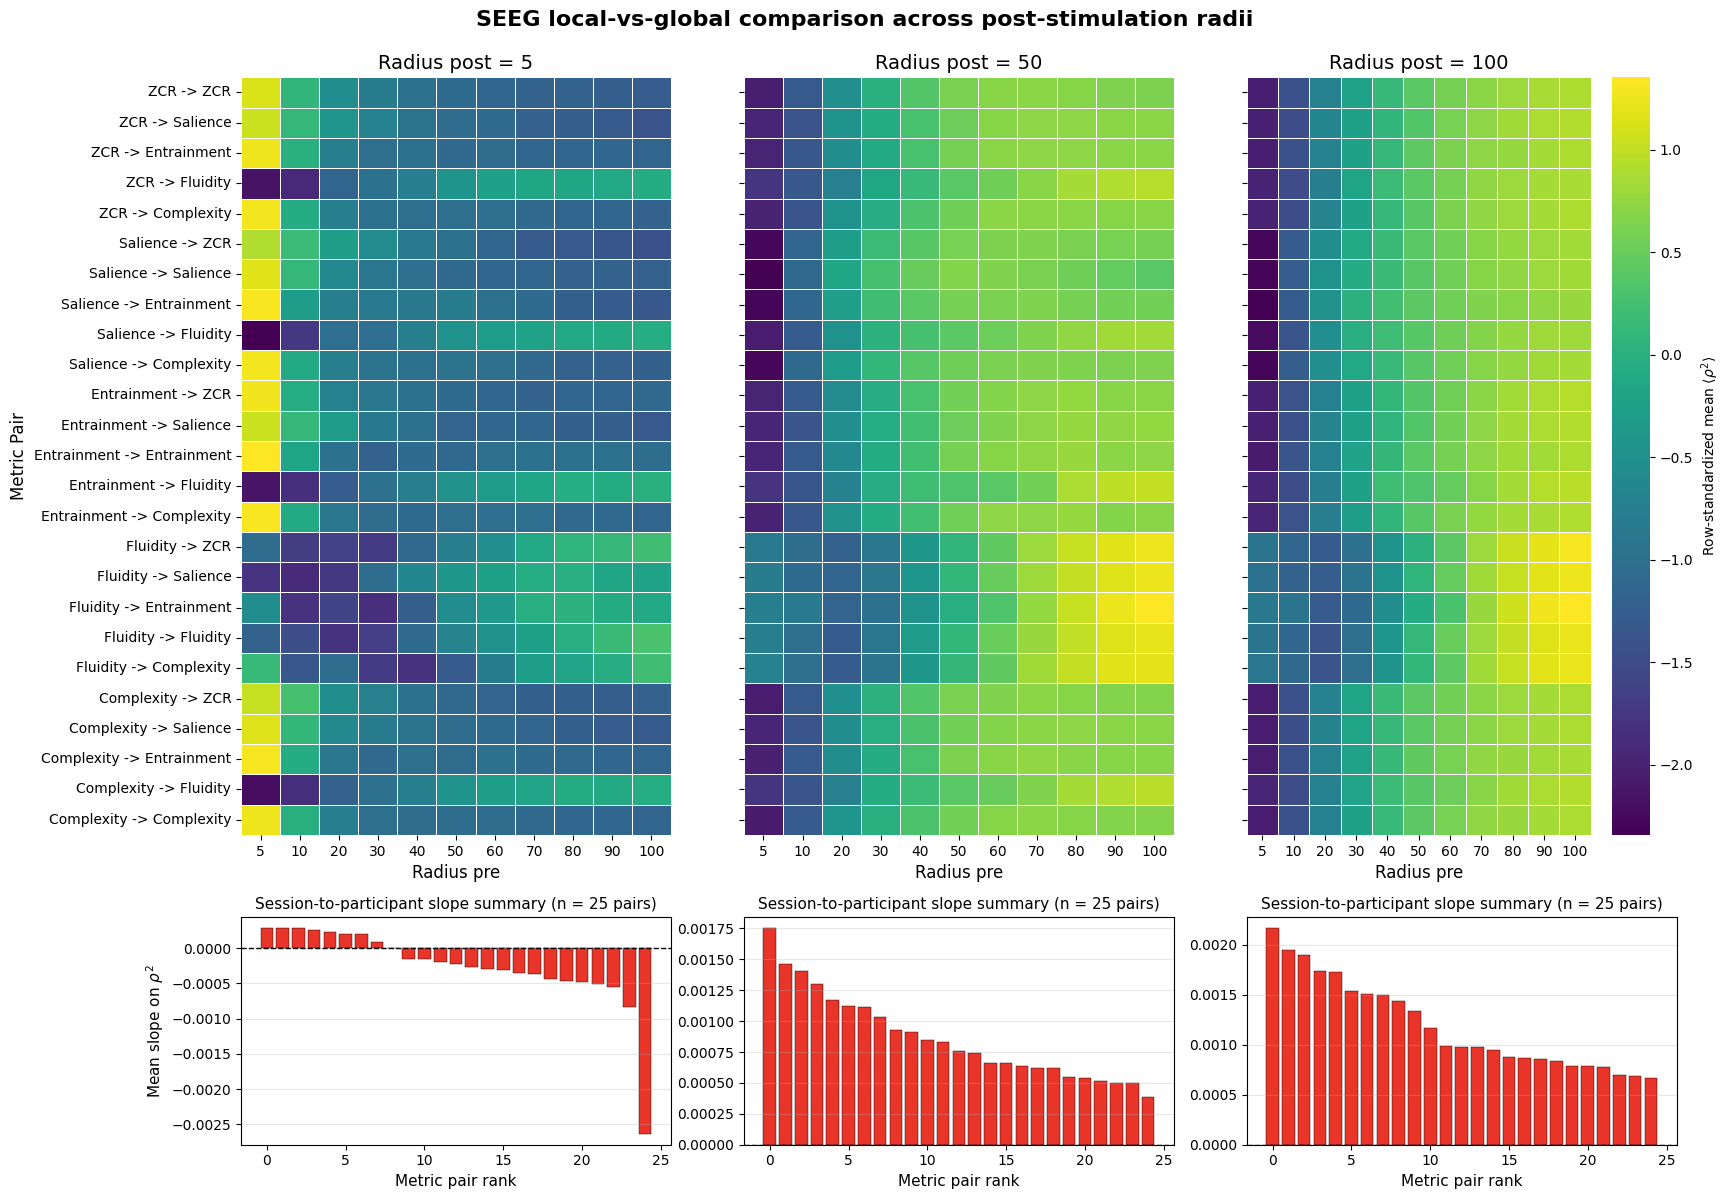

In [62]:
heatmap_index = [f'{pre} -> {post}' for pre in pair_order for post in pair_order]

fig, axes = plt.subplots(
    nrows=2,
    ncols=len(POST_RADIUS_VALUES),
    figsize=(5.8 * len(POST_RADIUS_VALUES), 12),
    gridspec_kw={'height_ratios': [10, 3]},
)

for column_index, radius_post in enumerate(POST_RADIUS_VALUES):
    ax_heatmap = axes[0, column_index]
    radius_post_df = df_radius_post_compare[
        df_radius_post_compare['Radius_post'] == radius_post
    ].copy()
    radius_post_df['Metric_pre'] = pd.Categorical(
        radius_post_df['Metric_pre'], categories=pair_order, ordered=True
    )
    radius_post_df['Metric_post'] = pd.Categorical(
        radius_post_df['Metric_post'], categories=pair_order, ordered=True
    )
    heatmap_summary = (
        radius_post_df.groupby(
            ['Metric_pre', 'Metric_post', 'Radius_pre'], observed=True
        )['Explained_Variance']
        .mean()
        .reset_index()
    )
    heatmap_summary['Metric_Pair'] = (
        heatmap_summary['Metric_pre'].astype(str)
        + ' -> '
        + heatmap_summary['Metric_post'].astype(str)
    )
    heatmap_data = heatmap_summary.pivot(
        index='Metric_Pair', columns='Radius_pre', values='Explained_Variance'
    )
    heatmap_data = heatmap_data.reindex(index=heatmap_index)
    row_std = heatmap_data.std(axis=1).replace(0, np.nan)
    heatmap_data_standardized = heatmap_data.sub(heatmap_data.mean(axis=1), axis=0)
    heatmap_data_standardized = heatmap_data_standardized.div(row_std, axis=0)

    sns.heatmap(
        heatmap_data_standardized,
        cmap='viridis',
        linewidths=0.4,
        cbar=column_index == len(POST_RADIUS_VALUES) - 1,
        cbar_kws={'label': 'Row-standardized mean ' + r'$\langle\rho^2\rangle$'},
        ax=ax_heatmap,
    )
    ax_heatmap.set_title(f'Radius post = {radius_post}', fontsize=14)
    ax_heatmap.set_xlabel('Radius pre', fontsize=12)
    if column_index == 0:
        ax_heatmap.set_ylabel('Metric Pair', fontsize=12)
    else:
        ax_heatmap.set_ylabel('')
        ax_heatmap.set_yticklabels([])

    ax_box = axes[1, column_index]
    slope_subset = comparison_summary_df[
        comparison_summary_df['Radius_post'] == radius_post
    ].sort_values('Mean participant slope on rho^2', ascending=False)
    ax_box.axhline(0, color='black', linestyle='--', linewidth=1)
    ax_box.bar(
        range(len(slope_subset)),
        slope_subset['Mean participant slope on rho^2'],
        color=plt.get_cmap('Reds')(0.65),
        edgecolor='black',
        linewidth=0.3,
    )
    ax_box.set_title(
        f'Session-to-participant slope summary (n = {len(slope_subset)} pairs)',
        fontsize=11,
    )
    ax_box.set_xlabel('Metric pair rank', fontsize=11)
    if column_index == 0:
        ax_box.set_ylabel(r'Mean slope on $\rho^2$', fontsize=11)
    else:
        ax_box.set_ylabel('')
    ax_box.grid(True, axis='y', alpha=0.3)

fig.suptitle(
    'SEEG local-vs-global comparison across post-stimulation radii',
    fontsize=16,
    y=0.995,
    fontweight='bold',
)
fig.tight_layout()
fig.savefig(radius_post_comparison_path, dpi=300, bbox_inches='tight')
print(f'Saved figure: {radius_post_comparison_path}')

comparison_summary_df.sort_values(
    ['Radius_post', 'Mean participant slope on rho^2'],
    ascending=[True, False],
).head(15)

# Aggregate Radius-Pre vs Radius-Post Summary

This final summary plot averages explained variance across sessions and metric pairs, and overlays the trajectories for `Radius_post = 5`, `50`, and `100`. It is intended to make the local-to-local (`5 -> 5`), global-to-global (`100 -> 100`), and intermediate-target comparisons such as `100 -> 50` versus `5 -> 50` easier to see directly in a single panel.

Saved figure: /Users/cbc/Documents/GitHub/fufo/notebook/DavideMomi/Revision/State_Dependent_Brain_Stimulation-main/results/figures/Suppl_Figure_radius_post_overlay_SEEG.png


,Radius_pre,Radius_post,Comparison,Mean explained variance,SEM,Session x metric-pair observations
0,5,5,Local to local (5 -> 5),0.083560,0.001370,7950
1,100,100,Global to global (100 -> 100),0.175986,0.001837,7950
2,5,50,Local to intermediate (5 -> 50),0.059654,0.000896,7950
3,100,50,Global to intermediate (100 -> 50),0.147904,0.001668,7950


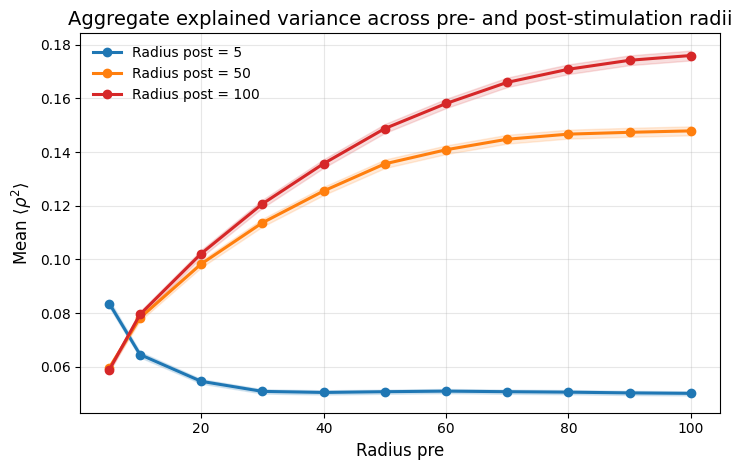

In [64]:
aggregate_radius_summary_path = figure_dir / 'Suppl_Figure_radius_post_overlay_SEEG.png'

aggregate_radius_summary = (
    df_radius_post_compare.groupby(['Radius_post', 'Radius_pre'], as_index=False)['Explained_Variance']
    .agg(mean='mean', sem='sem', count='size')
)
aggregate_radius_summary['sem'] = aggregate_radius_summary['sem'].fillna(0.0)
aggregate_radius_summary['lower'] = aggregate_radius_summary['mean'] - aggregate_radius_summary['sem']
aggregate_radius_summary['upper'] = aggregate_radius_summary['mean'] + aggregate_radius_summary['sem']

focus_radius_pairs = pd.DataFrame(
    [
        {'Radius_pre': 5, 'Radius_post': 5, 'Comparison': 'Local to local (5 -> 5)'},
        {'Radius_pre': 100, 'Radius_post': 100, 'Comparison': 'Global to global (100 -> 100)'},
        {'Radius_pre': 5, 'Radius_post': 50, 'Comparison': 'Local to intermediate (5 -> 50)'},
        {'Radius_pre': 100, 'Radius_post': 50, 'Comparison': 'Global to intermediate (100 -> 50)'},
    ]
)

focus_radius_summary = focus_radius_pairs.merge(
    aggregate_radius_summary[['Radius_pre', 'Radius_post', 'mean', 'sem', 'count']],
    on=['Radius_pre', 'Radius_post'],
    how='left',
)
focus_radius_summary = focus_radius_summary.rename(
    columns={
        'mean': 'Mean explained variance',
        'sem': 'SEM',
        'count': 'Session x metric-pair observations',
    }
)

fig, ax = plt.subplots(figsize=(7.4, 4.8))
palette = {5: '#1f77b4', 50: '#ff7f0e', 100: '#d62728'}

for radius_post in POST_RADIUS_VALUES:
    sub_df = aggregate_radius_summary[
        aggregate_radius_summary['Radius_post'] == radius_post
    ].sort_values('Radius_pre')
    ax.plot(
        sub_df['Radius_pre'],
        sub_df['mean'],
        marker='o',
        linewidth=2.2,
        color=palette[radius_post],
        label=f'Radius post = {radius_post}',
    )
    ax.fill_between(
        sub_df['Radius_pre'],
        sub_df['lower'],
        sub_df['upper'],
        color=palette[radius_post],
        alpha=0.15,
    )

ax.set_xlabel('Radius pre', fontsize=12)
ax.set_ylabel(r'Mean $\langle \rho^2 \rangle$', fontsize=12)
ax.set_title('Aggregate explained variance across pre- and post-stimulation radii', fontsize=14)
ax.grid(True, alpha=0.3)
ax.legend(frameon=False, loc='upper left')

radius_50_points = aggregate_radius_summary[
    aggregate_radius_summary['Radius_post'] == 50
].set_index('Radius_pre')

# if 5 in radius_50_points.index and 100 in radius_50_points.index:
#     diff_100_vs_5_for_50 = (
#         radius_50_points.loc[100, 'mean'] - radius_50_points.loc[5, 'mean']
#     )
#     ax.text(
#         0.98,
#         0.05,
#         'For Radius post = 50:\n'
#         + rf'$\langle\rho^2\rangle_{{100 \to 50}} - \langle\rho^2\rangle_{{5 \to 50}} = {diff_100_vs_5_for_50:.4f}$',
#         transform=ax.transAxes,
#         ha='right',
#         va='bottom',
#         fontsize=10,
#         bbox=dict(facecolor='white', alpha=0.9, edgecolor='0.7'),
#     )

fig.tight_layout()
fig.savefig(aggregate_radius_summary_path, dpi=300, bbox_inches='tight')
print(f'Saved figure: {aggregate_radius_summary_path}')

focus_radius_summary

Saved figure: /Users/cbc/Documents/GitHub/fufo/notebook/DavideMomi/Revision/State_Dependent_Brain_Stimulation-main/results/figures/Suppl_Figure_radius50_boxplot_SEEG.png


,Comparison,Mean explained variance,Median explained variance,SD,Observations
1,5 -> 50,0.059654,0.028983,0.079897,7950
2,50 -> 50,0.135619,0.086078,0.142086,7950
0,100 -> 50,0.147904,0.098736,0.148717,7950


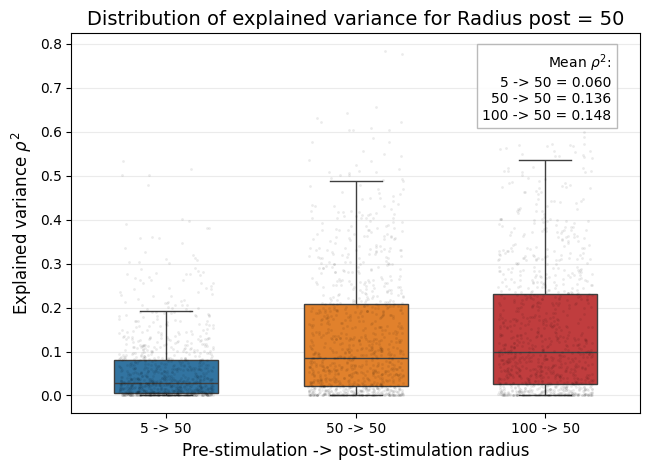

In [71]:
radius_50_boxplot_path = figure_dir / 'Suppl_Figure_radius50_boxplot_SEEG.png'

radius_50_boxplot_df = df_radius_post_compare[
    (df_radius_post_compare['Radius_post'] == 50)
    & (df_radius_post_compare['Radius_pre'].isin([5, 50, 100]))
][['Participant', 'Session', 'Metric_pre', 'Metric_post', 'Radius_pre', 'Explained_Variance']].copy()

radius_50_boxplot_df['Comparison'] = radius_50_boxplot_df['Radius_pre'].map({
    5: '5 -> 50',
    50: '50 -> 50',
    100: '100 -> 50',
})

comparison_order = ['5 -> 50', '50 -> 50', '100 -> 50']
palette_box = {
    '5 -> 50': '#1f77b4',
    '50 -> 50': '#ff7f0e',
    '100 -> 50': '#d62728',
}

radius_50_boxplot_summary = (
    radius_50_boxplot_df.groupby('Comparison', as_index=False)
    .agg(
        **{
            'Mean explained variance': ('Explained_Variance', 'mean'),
            'Median explained variance': ('Explained_Variance', 'median'),
            'SD': ('Explained_Variance', 'std'),
            'Observations': ('Explained_Variance', 'size'),
        }
    )
)
radius_50_boxplot_summary['Comparison'] = pd.Categorical(
    radius_50_boxplot_summary['Comparison'],
    categories=comparison_order,
    ordered=True,
)
radius_50_boxplot_summary = radius_50_boxplot_summary.sort_values('Comparison')

fig, ax = plt.subplots(figsize=(6.6, 4.8))
sns.boxplot(
    data=radius_50_boxplot_df,
    x='Comparison',
    y='Explained_Variance',
    hue='Comparison',
    order=comparison_order,
    palette=palette_box,
    dodge=False,
    width=0.55,
    linewidth=1,
    showfliers=False,
    legend=False,
    ax=ax,
 )
sns.stripplot(
    data=radius_50_boxplot_df.sample(min(len(radius_50_boxplot_df), 3000), random_state=0),
    x='Comparison',
    y='Explained_Variance',
    order=comparison_order,
    color='black',
    alpha=0.08,
    size=2,
    jitter=0.25,
    ax=ax,
 )

ax.set_xlabel('Pre-stimulation -> post-stimulation radius', fontsize=12)
ax.set_ylabel(r'Explained variance $\rho^2$', fontsize=12)
ax.set_title('Distribution of explained variance for Radius post = 50', fontsize=14)
ax.grid(True, axis='y', alpha=0.25)

means_for_annotation = radius_50_boxplot_summary.set_index('Comparison')['Mean explained variance']
annotation_text = (
    'Mean $\\rho^2$:\n'
    + f"5 -> 50 = {means_for_annotation['5 -> 50']:.3f}\n"
    + f"50 -> 50 = {means_for_annotation['50 -> 50']:.3f}\n"
    + f"100 -> 50 = {means_for_annotation['100 -> 50']:.3f}"
)
ax.text(
    0.95,
    0.95,
    annotation_text,
    transform=ax.transAxes,
    ha='right',
    va='top',
    fontsize=10,
    bbox=dict(facecolor='white', alpha=0.9, edgecolor='0.7'),
)

fig.tight_layout()
fig.savefig(radius_50_boxplot_path, dpi=300, bbox_inches='tight')
print(f'Saved figure: {radius_50_boxplot_path}')

radius_50_boxplot_summary